In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]
[100.      91.6875  83.75    76.1875  69.      62.1875  55.75    49.6875
  44.      38.6875  33.75    29.1875  25.      21.1875  17.75    14.6875
  12.       9.6875   7.75     6.1875   5.       4.1875   3.75     3.6875
   4.       4.6875   5.75     7.1875   9.      11.1875  13.75    16.6875
  20.      23.6875  27.75    32.1875  37.      42.1875  47.75    53.6875]


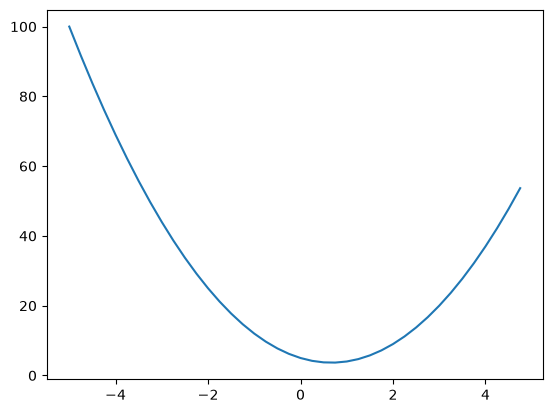

In [4]:
xs = np.arange(-5, 5, 0.25)
print(xs)
ys = f(xs)
print(ys)
plt.plot(xs, ys)

In [5]:
h = 0.001
x = 3.0
(f(x+h) - f(x))/h

14.00300000000243

In [6]:
a=2
b=-3.0
c=10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.00001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print("d1" ,  d1)
print("d2" ,  d2)
print("slope " , (d2 - d1)/h)


d1 4.0
d2 4.00001
slope  0.9999999999621422


In [26]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+') 

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data **(other-1)) * out.grad

        out._backward = _backward   
        return out

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other) 

    def __radd__(self, other):
        return self + other

    def __rsub__(self, other):
        return other + (-self)    

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/ (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad            
        out._backward = _backward
        return out

    def exp(self):   
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)

                for child in v._prev:
                    build_topo(child)
                topo.append(v)    
        build_topo(self);

        self.grad = 1.0;
        for node in reversed(topo):
            node._backward()

In [27]:
a = Value(2.0)
b = Value(4.0)

c = a+b
c._prev

hehe


{Value(data=2.0), Value(data=4.0)}

In [10]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()


    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir' : 'LR'}) #LR left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name= uid, label= "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')

        if n._op:
            dot.node(name= uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)


    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot;    
        

In [11]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#Weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# Bias
b = Value(6.8813735870195432, label='b')

#x1w1, x2w2
x1w1 = x1*w1
x1w1.label = 'x1w1'

x2w2 = x2*w2
x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'

o = n.tanh()
o.label = 'o'
o.backward()

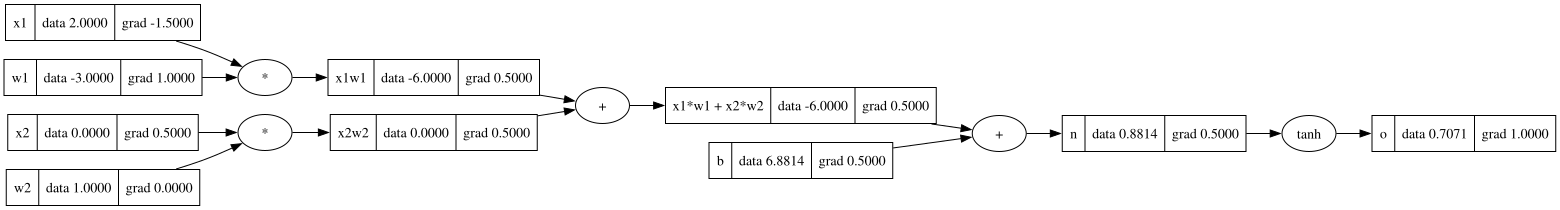

In [12]:
draw_dot(o)

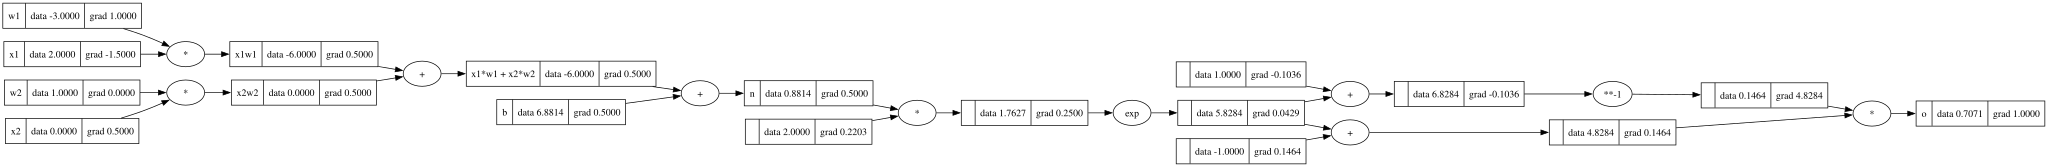

In [13]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#Weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# Bias
b = Value(6.8813735870195432, label='b')

#x1w1, x2w2
x1w1 = x1*w1
x1w1.label = 'x1w1'

x2w2 = x2*w2
x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'

e = (2*n).exp()
o = (e - 1)/(e + 1)

o.label = 'o'
o.backward()
draw_dot(o)

In [14]:
import torch

In [15]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True

w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double()
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('-----')
print(x2.grad.item())
print(w2.grad.item())
print(x1.grad.item())
print(w1.grad.item())


0.7071066904050358
-----
0.5000001283844369
0.0
-1.5000003851533106
1.0000002567688737


In [16]:
class Neuron:
    def __init__(self, nin): # nin - no of inputs
        self.w = [Value(random.uniform(-1,1)) for _ in range (nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []

        for neuron in self.neurons:
            params.extend(neuron.parameters())

        return params

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x    
        
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [17]:
x = [2.0, 3.0, -1.0]    
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.7360062839717764)

In [18]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

In [19]:
ypred = [n(x) for x in xs]
ypred

[Value(data=0.7360062839717764),
 Value(data=0.7502693460135277),
 Value(data=0.9595437696984432),
 Value(data=0.8270226673415053)]

In [20]:
for k in range(20):

    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)    
        


0 7.002868408674645
1 6.374166790029464
2 5.214548570585053
3 4.248642175471497
4 3.7776290185383927
5 3.242021648238218
6 2.0394562750739422
7 0.7030778602332381
8 0.37550419156488657
9 0.2604161080417908
10 0.19886597722048396
11 0.16004382106290665
12 0.13336456918794282
13 0.11395236494230107
14 0.09923015129672498
15 0.08770571799238203
16 0.0784555720525831
17 0.07087813889702457
18 0.06456517651174659
19 0.05923018769926004


In [21]:
ypred

[Value(data=0.8837002812596587),
 Value(data=-0.9457402430678148),
 Value(data=-0.8257174566806815),
 Value(data=0.8887074261597495)]